# Customer Purchasing Behaviours

https://www.kaggle.com/datasets/hanaksoy/customer-purchasing-behaviors/data

## EDA (Exploratory Data Analysis)

### Preparing the dataset

In [3]:
#Installation of Packages
#pip install pandas

In [4]:
# Importing Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
"""
Used url in the github repo so that the code is very reproducible by anyone.
"""

url = "https://github.com/hamedabangar/customer_purchasing_behaviors/raw/main/data/raw/Customer%20Purchasing%20Behaviors.csv"

df = pd.read_csv(url)
df.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


### Quick Overview 

In [6]:
df.shape

(238, 7)

This dataset has 238 rows and 7 columns

In [7]:
#check for null
df.isnull().sum()

user_id               0
age                   0
annual_income         0
purchase_amount       0
loyalty_score         0
region                0
purchase_frequency    0
dtype: int64

There are no null values

In [8]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

There are 0 duplicated values 

### Reorganization of Columns

Decided to reorganize the columns for better readability.

For instance, data concerning customer's characteristics (age, region) were first then transactional data in the later parts. 

In [9]:
#re-organizing columns
df = df[['user_id', 'region', 'age', 'annual_income', 
         'loyalty_score', 'purchase_amount', 'purchase_frequency']]

It appears that as a business, our objective is to **maximize purchase amount and purchase frequency.**

Create new label/colunn **purchase_total**
which can be derived by purchase_amount * purchase_frequency. 
<br>

As a business, our objective would be to maximize purchase_total ; which can be achieved by increasing purchase_amount and purchase_frequency

In [10]:
df['purchase_total'] = df['purchase_amount'] * df['purchase_frequency']

### Preliminary Analysis

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   region              238 non-null    object 
 2   age                 238 non-null    int64  
 3   annual_income       238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   purchase_amount     238 non-null    int64  
 6   purchase_frequency  238 non-null    int64  
 7   purchase_total      238 non-null    int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 15.0+ KB


In [12]:
"""
Note about 'describe':
describe() does not assume or imply a bell-curve (normal) distribution.
"""

df.describe().T #T -> Transpose (flips rows and columns) 

,count,mean,std,min,25%,50%,75%,max
user_id,238.0,119.500000,68.848868,1.0,60.25,119.5,178.750,238.0
age,238.0,38.676471,9.351118,22.0,31.00,39.0,46.750,55.0
annual_income,238.0,57407.563025,11403.875717,30000.0,50000.00,59000.0,66750.000,75000.0
loyalty_score,238.0,6.794118,1.899047,3.0,5.50,7.0,8.275,9.5
purchase_amount,238.0,425.630252,140.052062,150.0,320.00,440.0,527.500,640.0
purchase_frequency,238.0,19.798319,4.562884,10.0,17.00,20.0,23.000,28.0
purchase_total,238.0,9059.033613,4597.704379,1500.0,5200.00,9000.0,12132.500,17920.0


<u>Column's Range and Mean</u> <br>
**Age** : range from 22 to 55 ; mean = 39 <br>
**Annual Income** : range from $30,000 to $75,000 ; mean = $57,407.56 <br>
**Loyalty Score** : range from 3.0 to 9.5 ; mean = 6.8 <br>
**Purchase Amount** : range from $150 to $640 ; mean = $42 <br>
**Purcase Frequency** : range from 10 to 28 ; mean = 20 <br>
**Purchase Total** : range $1500 to $17,920 ; mean = $9059.03 <br>

In [13]:
region_stats = pd.DataFrame({
    'Count': df['region'].value_counts(),
    'Percentage': df['region'].value_counts(normalize=True) * 100
})

region_stats['Percentage'] = region_stats['Percentage'].round(1).astype(str) + '%'

region_stats


,Count,Percentage
region,,
North,78,32.8%
South,77,32.4%
West,77,32.4%
East,6,2.5%


What are some ways to balance out labels? 
-> SMOTE, XGBoost ; however, these are used when target label is imbalanced. The region column is NOT the label. 
<br>Therefore, **no balancing is needed**.

### Initial Hypothesis

In [14]:
region_summary = df.groupby('region').agg({
    'user_id': 'count',
    'age': 'mean',
    'annual_income': 'mean',
    'loyalty_score': 'mean',
    'purchase_amount': 'mean',
    'purchase_frequency': 'mean',
    'purchase_total': 'mean'
}).rename(columns={'user_id': 'Count'})

# Round all numeric columns to 2 decimals
region_summary = region_summary.round(2)

region_summary

,Count,age,annual_income,loyalty_score,purchase_amount,purchase_frequency,purchase_total
region,,,,,,,
East,6,31.67,49000.00,5.40,320.00,16.67,5830.00
North,78,34.36,53038.46,5.87,358.59,17.65,6796.28
South,77,38.00,55766.23,6.73,416.88,19.47,8750.39
West,77,44.27,64129.87,7.91,510.52,22.55,11911.43


Based on a quick glance, we can observe that counts of North, South, West is almost similar in counts of instances. Therefore, it is easy to make a direct comparison between North, South, West.
<br><br>
We can observe that West has highest average age, annual income, loyalty score, purchase amount, frequency and purchase total. ALL the variables are highest in 'West'. 
<br><br>
North > South > West ; this pattern is consistent throughout the dataset for ALL corresponding columns
<br><br>
Therefore, we can safely initially hypothesize that: <br>
"There appears to be a direct correlation between age and income. Higher the age, higher the income. And higher income determines that the loyalty score is higher, purchase amount is higher, purchase frequency is higher.
<br> 
Therefore, the focus should be to have clients with higher incomes. And, it happens that higher age clients have higher incomes. "

### Correlation

In [15]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Display
corr_matrix

,user_id,age,annual_income,loyalty_score,purchase_amount,purchase_frequency,purchase_total
user_id,1.000000,0.067061,0.059031,0.060819,0.080621,0.070541,0.073590
age,0.067061,1.000000,0.974833,0.981835,0.986140,0.980532,0.991009
annual_income,0.059031,0.974833,1.000000,0.984351,0.984208,0.982920,0.966854
loyalty_score,0.060819,0.981835,0.984351,1.000000,0.994147,0.986990,0.978267
purchase_amount,0.080621,0.986140,0.984208,0.994147,1.000000,0.993579,0.988883
purchase_frequency,0.070541,0.980532,0.982920,0.986990,0.993579,1.000000,0.987954
purchase_total,0.073590,0.991009,0.966854,0.978267,0.988883,0.987954,1.000000


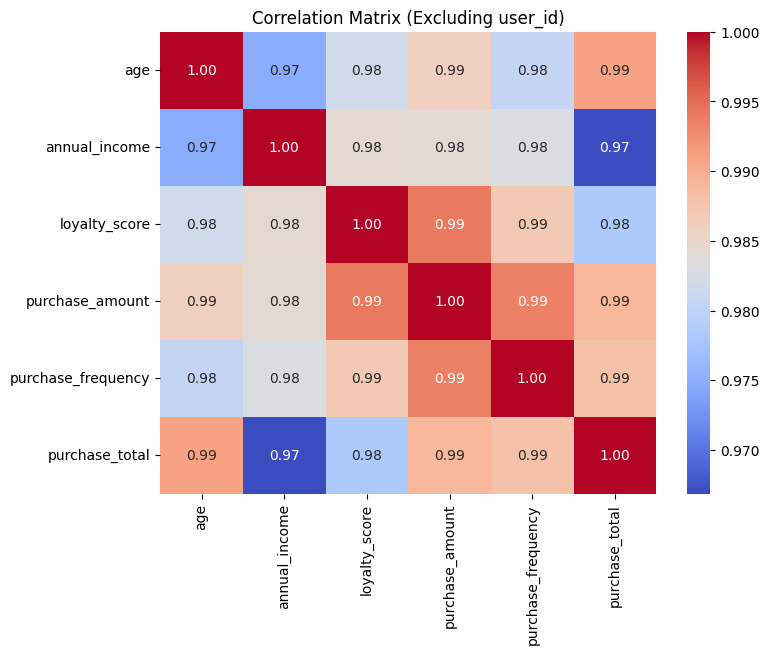

In [16]:
corr_matrix = df.drop(columns=['user_id']).corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Excluding user_id)')
plt.show()

The correlation matrix shows that the numeric features in the dataset are highly positively correlated with each other. 

Age, annual income, loyalty score, purchase amount, purchase frequency, and purchase total all exhibit correlations close to 0.97–0.99; almost perfect correlation. 

While strong correlations can provide useful insights, they also indicate multicollinearity (meaning some features capture very similar information). 

In our case, high income means high resultants.

### Visualizations

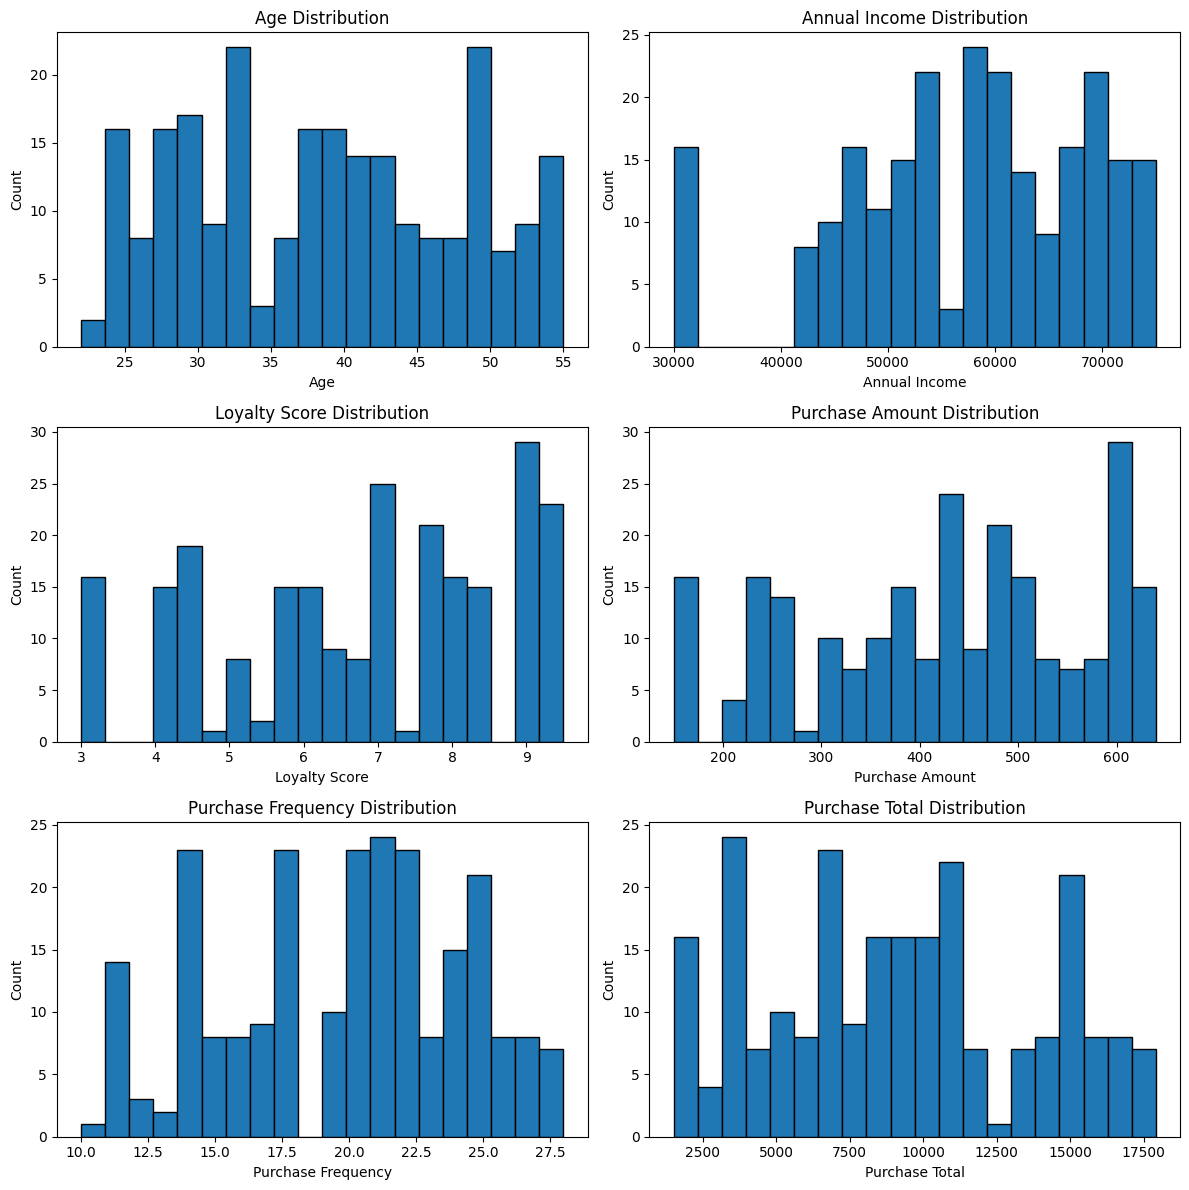

In [28]:
"""Visualizations of Distributions of Numeric Features"""

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

columns = [
    'age',
    'annual_income',
    'loyalty_score',
    'purchase_amount',
    'purchase_frequency',
    'purchase_total'
]

for i, col in enumerate(columns):
    axes[i].hist(df[col], bins=20, edgecolor='black')
    axes[i].set_title(f'{col.replace("_", " ").title()} Distribution')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

From observing the last 3 graphs (Purchase Amount, Purchase Frequency, Purchase Total): 

Since purchase total is the product of the two (amount * frequency), all three variables are highly positively correlated.

Customers who spend more per purchase or buy more frequently and especially those who do both, generate much higher purchase totals.

Therefore, we'd like to focus on customers who spend frequently and alot. 

***Most graphs seems to be of even distribution. However, by subsetting the data, we have uncovered discoveries that will be helpful for the business case by focusing on high frequency and high spending shoppers***

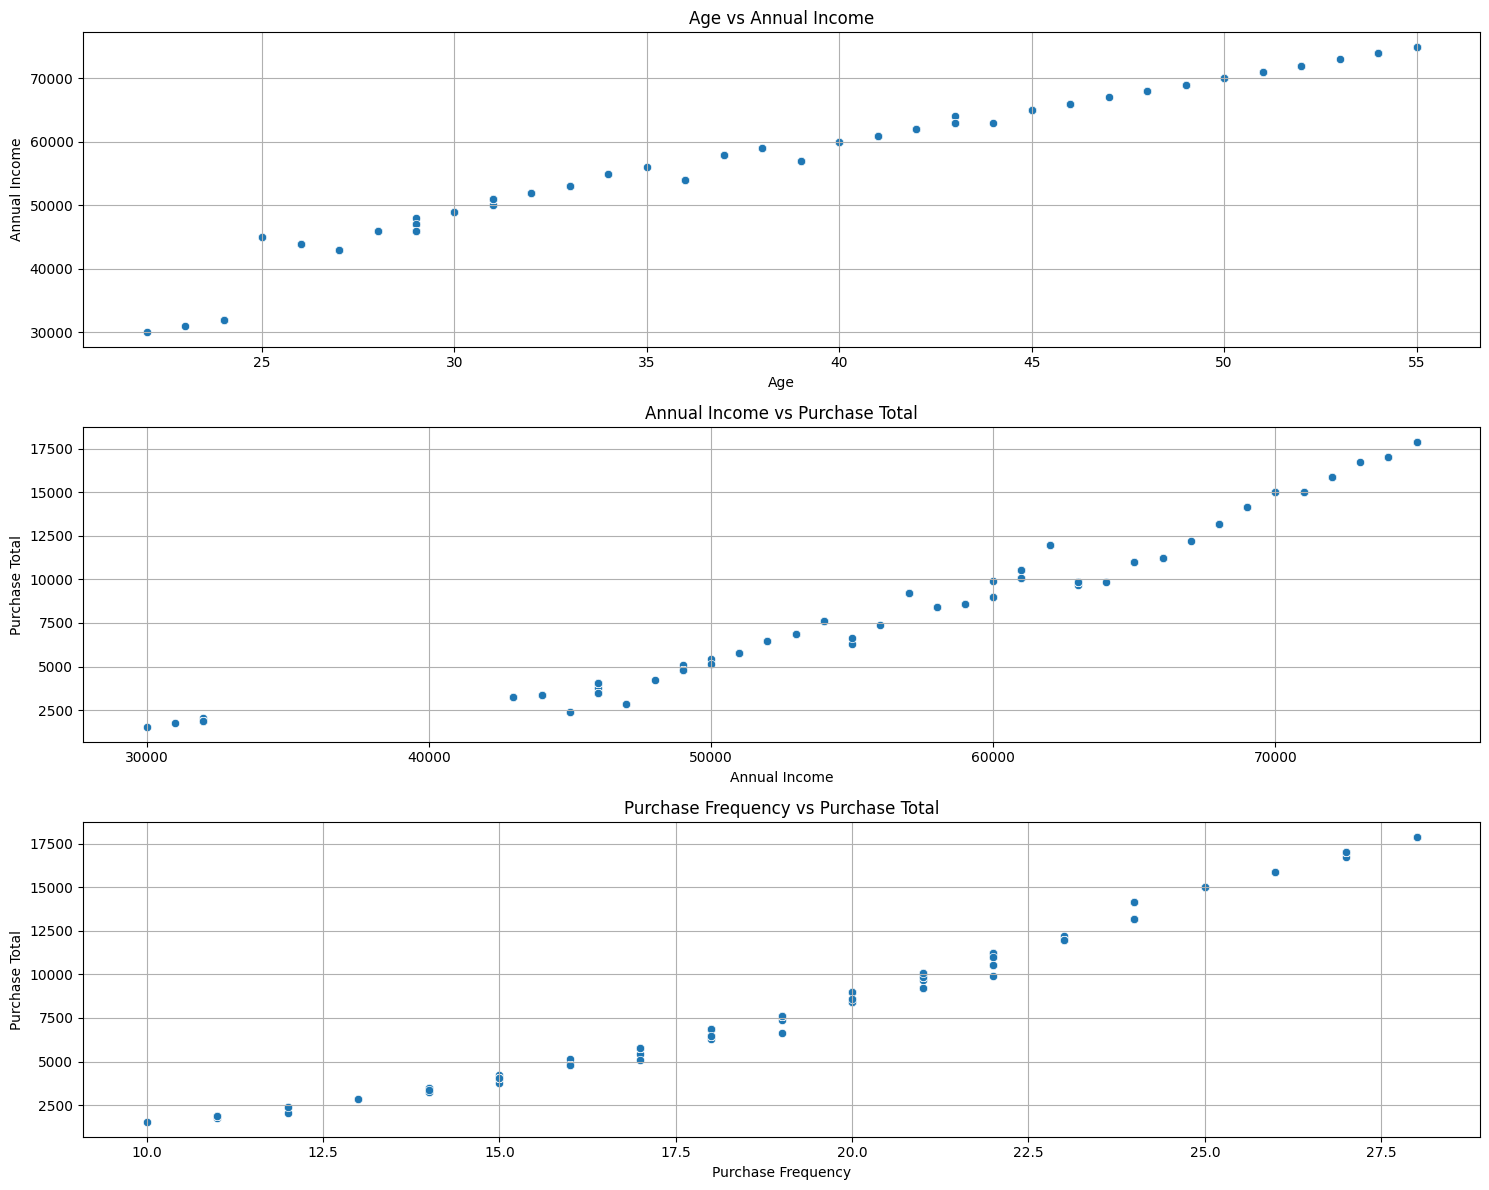

In [29]:
plt.figure(figsize=(15, 12))

# 1. Age vs Annual Income
plt.subplot(3, 1, 1)
sns.scatterplot(data=df, x='age', y='annual_income')
plt.title('Age vs Annual Income')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.grid(True)

# 2. Annual Income vs Purchase Total
plt.subplot(3, 1, 2)
sns.scatterplot(data=df, x='annual_income', y='purchase_total')
plt.title('Annual Income vs Purchase Total')
plt.xlabel('Annual Income')
plt.ylabel('Purchase Total')
plt.grid(True)

# 3. Purchase Frequency vs Purchase Total
plt.subplot(3, 1, 3)
sns.scatterplot(data=df, x='purchase_frequency', y='purchase_total')
plt.title('Purchase Frequency vs Purchase Total')
plt.xlabel('Purchase Frequency')
plt.ylabel('Purchase Total')
plt.grid(True)

plt.tight_layout()
plt.show()

***Age vs Income*** <br>
Almost perfectly linear correlation except for age ~25 to 27. Therefore, it can be assumed that higher age clients have higher income

***Annual Income vs Purchase Total*** <br>
Outliers at the bottom (~$30,000 to $32,000) but other than that, there is a very strong positive correlation between income and purcahses. Therefore, it can be assumed that higher income clients make more purchases.

***Purchase Freqeuency vs Purchase Total***
There are no outliers with this relationship. There is a very strong positive correlation between frequency and purchase total. Therefore, it can be assumed that clients that purchase more frequently also purchase more per purchase, hence, higher purchase total. 


### Subset of data of high frequency shoppers

Looking at the 'Purchase Frequency Distribution', we want to focus on characteristics of high frequency purchase clients. >25 was the ballpark figure used to focus.

In [30]:
#subset of data of high freqeuncy customers
high_freq_summary = (
    high_freq_df
    .drop(columns=['user_id'])
    .mean(numeric_only=True)
    .round(2)
)

high_freq_summary

age                      52.02
annual_income         72022.73
loyalty_score             9.19
purchase_amount         613.41
purchase_frequency       26.02
purchase_total        15980.23
dtype: float64

**Summary of High Frequency Shoppers**

We are able to conclude that though 'age' is an even distribution, higher age clients >50 are the ones purchasing frequently (>25). 

They also happen to be higher income (>$72,000), very high loyalty (>9), high spenders who spend more frequently at higher amounts (hence, also impacting purchase totals)

